# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Christiaan Paardenkooper| 6453902 |
| T.D.H.| Stude van Zeeland| 64795510 |
| Yael Jawahierkhan|6444504|
| Planning Groep: 11     | --- |
|---|---|
| Sanity checks af | 12:00 |
| sensor gemaakt te hebben | 15:00 |
| groep aanwezig 1| 10:42 |
| groep aanwezig 2| 13:32 |
| Pauze 1| 12:45-13:45 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets.jpeg" alt="schets student 1" width="400"/>

In [ ]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt

epsilon0 = 8.854e-12
epsilon_karton = 1.78

def vlakkeplaat(A,d,epsilon_r):
    C = ((epsilon0*epsilon_r*A )/ d)
    return C

def voltage(f, c, Vin, R):
    return f*c*2*np.pi*Vin*R


# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [ ]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C= vlakkeplaat(0.1**2, 0.001, epsilon_karton)
# C = [functieNaam(2.0), functieNaam(4.7),functieNaam(1.2)]
V = voltage(10**5, 1.478618e-10, 8, 1000)
print(V)

print(f"Berekende capaciteit plaatcondensator groep 11 is {C:} F")



0.7432344714025012
Berekende capaciteit plaatcondensator groep 11 is 1.576012e-10 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](condensator_makeshift.jpeg)
![iets](mettingen2.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 11| 1.576012 pF | 0.7432344714025012 | 0.665625V | 147.85 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets2.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

we gaan een sensor maken die kracht (N) meet

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](laatschets.jpeg)

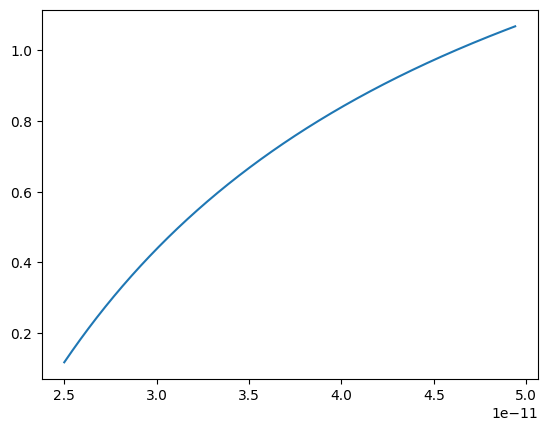

In [66]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


epsilon0 = 8.854e-12

epsilon_L = epsilon0*1.00056

A = (0.1)**2

epsilon_func = epsilon0*2.66

# Aannames:
# In deze benadering nemen wij aan dat de verandering in permittiviteit verwaarloosbaar is
# Wij schatten dat de relatieve permittivitei 2.66 is
# Wij nemen aan dat de draden geen weerstand hebben en dat er geen elektrische en/of magnetische velden van buitenaf komen.


def d(C):
    d = epsilon_func*A/C
    return d

# def d_a



xtest1 = np.linspace(min(x),max(x),1000)


def func(x,k):
    return k/9.81*(0.01-epsilon_func*A/x)

plt.figure()
plt.plot(xtest1,func(xtest1,2000))
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 |0 |
| gemiddelde capaciteit| 500 | 2.3 |
| maximale capaciteit| 1000 |4.097 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling0.jpeg)
![meting 1](mettingen.png)


## Opdracht 7: Plot de kalibratiegrafiek.

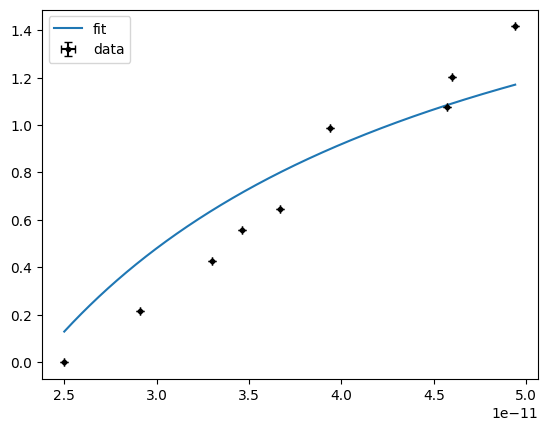

Onzekerheid is 149.8 in k, de gevonden waarde voor k is 2193.7


In [85]:
y= np.sort(np.array([0, 0.557, 0.9874, 1.4160, 0.2166, 0.4284,0.4284+0.2166, 0.4284+0.2166+0.5571, 0.4284+0.2166+0.4307 ]))
x=np.sort(np.array([25, 34.6, 39.4, 49.4, 33, 29.1, 36.7, 46, 45.7]))*1e-12
#onzekerheid is 0.5 g
#
xtest = np.linspace(min(x),max(x),1000)

u_m = 0.00005

val,cov = curve_fit(func,x,y)

plt.figure()
# plt.plot(x,y,'k.')
plt.plot(xtest,func(xtest,*val),label = "fit")
plt.errorbar(x,y,xerr = 0,yerr = 0.05/1000, capsize = 3,fmt = 'k.', label = "data")
plt.legend()
plt.show()

print("Onzekerheid is %.1f in k, de gevonden waarde voor k is %.1f" %(np.sqrt(cov[0,0]),val[0]))

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* we hebben sate prikkers onder de sensor gelegd zodat de sensor stabiel is en niet wibelde op de paperclip
* we hebben een ander zachtere spons gepakt die ook echt inzakt onder gewicht
* we hebben een spons gepakt die niet schuin was

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstelling1.jpeg)
![foto sensor](opstelling2.jpeg)

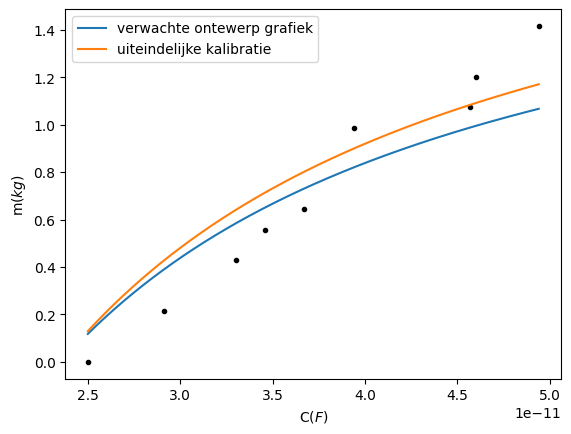

In [71]:
plt.figure()
plt.plot(x,y,'k.')
plt.plot(xtest,func(xtest,2000), label='verwachte ontewerp grafiek')
plt.plot(xtest,func(xtest,*val), label='uiteindelijke kalibratie')
plt.xlabel('C$(F)$')
plt.ylabel('m$(kg)$')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De sensor die wij hebben ontworpen is geschikt als weegschaal. k = 2193.7 +/- 149.8 [N/m] Om het te verbeteren als weegschaal zal er wel een fatsoenlijke standaard en weegplaat voor ontworpen moeten worden.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](laatschets.jpeg)

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets2.jpeg)


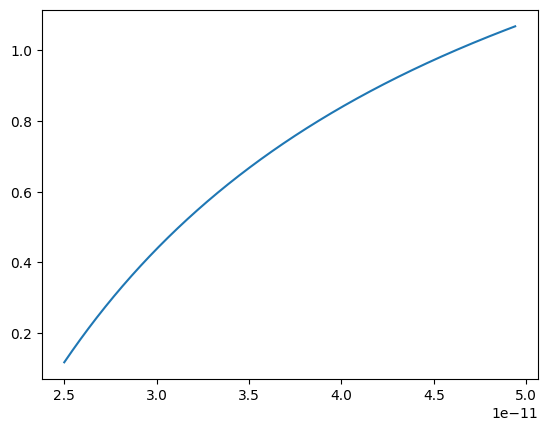

In [ ]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.


# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


epsilon0 = 8.854e-12

epsilon_L = epsilon0*1.00056

A = (0.1)**2

epsilon_func = epsilon0*2.66

# Aannames:
# In deze benadering nemen wij aan dat de verandering in permittiviteit verwaarloosbaar is
# Wij schatten dat de relatieve permittivitei 2.66 is
# Wij nemen aan dat de draden geen weerstand hebben en dat er geen elektrische en/of magnetische velden van buitenaf komen.


def d(C):
    d = epsilon_func*A/C
    return d

# def d_a



xtest1 = np.linspace(min(x),max(x),1000)


def func(x,k):
    return k/9.81*(0.01-epsilon_func*A/x)

plt.figure()
plt.plot(xtest1,func(xtest1,2000))
plt.show()


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling0.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

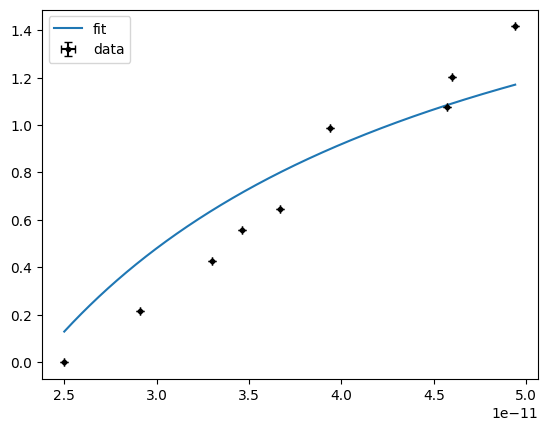

Onzekerheid is 149.8 in k, de gevonden waarde voor k is 2193.7


In [ ]:
y= np.sort(np.array([0, 0.557, 0.9874, 1.4160, 0.2166, 0.4284,0.4284+0.2166, 0.4284+0.2166+0.5571, 0.4284+0.2166+0.4307 ]))
x=np.sort(np.array([25, 34.6, 39.4, 49.4, 33, 29.1, 36.7, 46, 45.7]))*1e-12
#onzekerheid is 0.5 g
#
xtest = np.linspace(min(x),max(x),1000)

u_m = 0.00005

val,cov = curve_fit(func,x,y)

plt.figure()
# plt.plot(x,y,'k.')
plt.plot(xtest,func(xtest,*val),label = "fit")
plt.errorbar(x,y,xerr = 0,yerr = 0.05/1000, capsize = 3,fmt = 'k.', label = "data")
plt.legend()
plt.show()

print("Onzekerheid is %.1f in k, de gevonden waarde voor k is %.1f" %(np.sqrt(cov[0,0]),val[0]))